# 2025 Tournament Holdout Evaluation

**Goal**: Retrain the ensemble model (LR + XGBoost) on all data *except* 2025 tournament
games, then predict 2025 tournament outcomes and score against actual results.

**Key design**: Mirror the production pipeline exactly:
- Rolling snapshots computed from **all games** (regular season + tournament) -- but excluding 2025 tournament
- Models retrained on the same data (all games through 2024 + 2025 regular season)
- The 2025 tournament games are held out as the test set (never seen during training)
- Scored with **Brier score** and log-loss

In [1]:
import sys, os, json
from pathlib import Path

import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import brier_score_loss, log_loss, accuracy_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier

PROJECT_ROOT = Path(os.getcwd()).parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.data_loader import load_regular_season_results, load_tourney_results
from src.features import build_rolling_training_data, get_team_rolling_snapshot
from src.features import (
    build_team_season_stats,
    build_advanced_team_stats,
    add_strength_of_schedule,
    add_seed_features,
    add_massey_features,
    add_single_system_ranking,
    add_sos_adjusted_features,
)
from src.data_loader import load_seeds, load_massey_ordinals
from src.model import EnsemblePredictor

OUTPUT_DIR = PROJECT_ROOT / "outputs"
RANDOM_STATE = 42
print(f"Project root: {PROJECT_ROOT}")

Project root: /Users/sidthakur/Github/mm-2026


In [2]:
# Load feature column metadata (feature names, hyperparameters, weights)
with open(OUTPUT_DIR / "feature_columns.json", "r") as f:
    meta = json.load(f)

m_feat_cols = meta["m_feature_columns"]
w_feat_cols = meta["w_feature_columns"]

# Hyperparameters from Optuna tuning (saved in notebook 03)
m_best_params = {k: float(v) if '.' in str(v) else int(v) 
                 for k, v in meta["m_best_params"].items()}
w_best_params = {k: float(v) if '.' in str(v) else int(v) 
                 for k, v in meta["w_best_params"].items()}
m_ens_weights = meta["m_ensemble_weights"]
w_ens_weights = meta["w_ensemble_weights"]

print(f"Men's features:   {len(m_feat_cols)}")
print(f"Women's features: {len(w_feat_cols)}")
print(f"Men's ensemble:   LR({m_ens_weights[0]:.2f}) + XGB({m_ens_weights[1]:.2f})")
print(f"Women's ensemble: LR({w_ens_weights[0]:.2f}) + XGB({w_ens_weights[1]:.2f})")
print(f"Men's XGB params: {m_best_params}")
print(f"Women's XGB params: {w_best_params}")

Men's features:   24
Women's features: 20
Men's ensemble:   LR(0.68) + XGB(0.32)
Women's ensemble: LR(0.66) + XGB(0.34)
Men's XGB params: {'learning_rate': 0.029450130799794694, 'n_estimators': 399, 'max_depth': 3, 'subsample': 0.7554481710668257, 'colsample_bytree': 0.8432237349601533, 'reg_alpha': 0.06905982406782249, 'reg_lambda': 0.05654750607042966, 'min_child_weight': 8}
Women's XGB params: {'learning_rate': 0.03957057636993966, 'n_estimators': 445, 'max_depth': 3, 'subsample': 0.7760789208386777, 'colsample_bytree': 0.7967591652396122, 'reg_alpha': 0.6653292285205781, 'reg_lambda': 0.1465449117440177, 'min_child_weight': 11}


## Build Training Data and Snapshots (All Games, Excluding 2025 Tournament)

**Key change from previous version**: We now include tournament games from prior years
in the rolling windows, matching the production pipeline (notebook 02). The data includes:

- All regular season games (2003-2025 for men, 2010-2025 for women)
- All tournament games from 2003-2024 (for men) / 2010-2024 (for women)
- **Excludes** 2025 tournament games (those are the test set we predict)

This means rolling window snapshots for 2025 teams still reflect end-of-regular-season form
(no 2025 tournament data exists in the input), but teams from prior seasons correctly have
their tournament games factored into rolling windows -- matching production exactly.

In [3]:
%%time
# ============================================================
# 1. Load all game data (regular season + tournament)
# ============================================================
print("Loading game data...")
m_detailed_rs = load_regular_season_results(gender="M", detailed=True)
m_compact_rs = load_regular_season_results(gender="M", detailed=False)
m_tourney_detailed = load_tourney_results(gender="M", detailed=True)
m_tourney_compact = load_tourney_results(gender="M", detailed=False)

w_detailed_rs = load_regular_season_results(gender="W", detailed=True)
w_compact_rs = load_regular_season_results(gender="W", detailed=False)
w_tourney_detailed = load_tourney_results(gender="W", detailed=True)
w_tourney_compact = load_tourney_results(gender="W", detailed=False)

# Exclude 2025 tournament games (those are the test set)
m_tourney_detailed_pre2025 = m_tourney_detailed[m_tourney_detailed["Season"] < 2025].copy()
m_tourney_compact_pre2025 = m_tourney_compact[m_tourney_compact["Season"] < 2025].copy()
w_tourney_detailed_pre2025 = w_tourney_detailed[w_tourney_detailed["Season"] < 2025].copy()
w_tourney_compact_pre2025 = w_tourney_compact[w_tourney_compact["Season"] < 2025].copy()

# Combine: all regular season + tournament games EXCEPT 2025 tournament
m_all_detailed = pd.concat([m_detailed_rs, m_tourney_detailed_pre2025], ignore_index=True)
m_all_compact = pd.concat([m_compact_rs, m_tourney_compact_pre2025], ignore_index=True)
w_all_detailed = pd.concat([w_detailed_rs, w_tourney_detailed_pre2025], ignore_index=True)
w_all_compact = pd.concat([w_compact_rs, w_tourney_compact_pre2025], ignore_index=True)

print(f"Men's total games (excl. 2025 tourney): {len(m_all_detailed):,}")
print(f"  Regular season: {len(m_detailed_rs):,}")
print(f"  Tournament (pre-2025): {len(m_tourney_detailed_pre2025):,}")
print(f"Women's total games (excl. 2025 tourney): {len(w_all_detailed):,}")
print(f"  Regular season: {len(w_detailed_rs):,}")
print(f"  Tournament (pre-2025): {len(w_tourney_detailed_pre2025):,}")

# ============================================================
# 2. Build static season-level features (same as notebook 02)
# ============================================================
print("\nBuilding static season-level features...")

# Men's base stats (uses regular season only, matching notebook 02)
m_stats = build_team_season_stats(m_detailed_rs, compact_results_df=m_compact_rs)
m_adv = build_advanced_team_stats(m_detailed_rs, compact_results_df=m_compact_rs)
m_stats = m_stats.join(m_adv, how="left")
m_stats = add_strength_of_schedule(m_stats, m_detailed_rs, m_compact_rs)

m_seeds = load_seeds(gender="M")
m_stats = add_seed_features(m_stats, m_seeds)

print("Loading Massey ordinals (men's only)...")
ordinals_df = load_massey_ordinals()
m_stats = add_massey_features(m_stats, ordinals_df)
m_stats = add_single_system_ranking(m_stats, ordinals_df, system_name="POM", col_name="kenpom_rank")
m_stats = add_sos_adjusted_features(m_stats)

m_stats["neutral_win_pct"] = m_stats["neutral_win_pct"].fillna(m_stats["win_pct"])
m_stats["away_win_pct"] = m_stats["away_win_pct"].fillna(m_stats["win_pct"])

# Women's base stats
w_stats = build_team_season_stats(w_detailed_rs, compact_results_df=w_compact_rs)
w_adv = build_advanced_team_stats(w_detailed_rs, compact_results_df=w_compact_rs)
w_stats = w_stats.join(w_adv, how="left")
w_stats = add_strength_of_schedule(w_stats, w_detailed_rs, w_compact_rs)

w_seeds = load_seeds(gender="W")
w_stats = add_seed_features(w_stats, w_seeds)
w_stats = add_sos_adjusted_features(w_stats)

w_stats["neutral_win_pct"] = w_stats["neutral_win_pct"].fillna(w_stats["win_pct"])
w_stats["away_win_pct"] = w_stats["away_win_pct"].fillna(w_stats["win_pct"])

# Prepare static feature subsets for rolling training data
m_static_cols = ["sos", "win_pct", "efficiency_margin", "kenpom_rank", "sos_adj_eff_margin"]
m_static = m_stats[[c for c in m_static_cols if c in m_stats.columns]].copy()
m_static["kenpom_rank"] = m_static["kenpom_rank"].fillna(366)

w_static_cols = ["sos", "win_pct", "efficiency_margin", "sos_adj_eff_margin"]
w_static = w_stats[[c for c in w_static_cols if c in w_stats.columns]].copy()

print(f"Men's static features: {list(m_static.columns)}")
print(f"Women's static features: {list(w_static.columns)}")

# ============================================================
# 3. Build rolling window training data (all games excl. 2025 tourney)
# ============================================================
print("\nBuilding rolling window training data (this takes a few minutes)...")
m_train = build_rolling_training_data(
    m_all_detailed, compact_results_df=m_all_compact,
    team_stats=m_static, windows=(5, 7, 10),
)

w_train = build_rolling_training_data(
    w_all_detailed, compact_results_df=w_all_compact,
    team_stats=w_static, windows=(5, 7, 10),
)

# Drop rows with NaN in feature columns
m_all_feat = [c for c in m_train.columns if c not in ("target", "Season", "DayNum", "TeamA", "TeamB", "is_tourney")]
w_all_feat = [c for c in w_train.columns if c not in ("target", "Season", "DayNum", "TeamA", "TeamB", "is_tourney")]
m_train = m_train.dropna(subset=m_all_feat).reset_index(drop=True)
w_train = w_train.dropna(subset=w_all_feat).reset_index(drop=True)

print(f"Men's training rows:   {len(m_train):,}")
print(f"  Tourney rows: {m_train['is_tourney'].sum():,}")
print(f"Women's training rows: {len(w_train):,}")
print(f"  Tourney rows: {w_train['is_tourney'].sum():,}")

# ============================================================
# 4. Train holdout models (exclude 2025 tournament, include everything else)
# ============================================================
# Filter to training range: all seasons up to 2025 (but 2025 tourney already excluded)
m_train_mask = (m_train["Season"] >= 2003) & (m_train["Season"] <= 2025)
w_train_mask = (w_train["Season"] >= 2010) & (w_train["Season"] <= 2025)

m_X = m_train.loc[m_train_mask, m_feat_cols].copy()
m_y = m_train.loc[m_train_mask, "target"].copy()
w_X = w_train.loc[w_train_mask, w_feat_cols].copy()
w_y = w_train.loc[w_train_mask, "target"].copy()

# Fill NaN with training medians
m_medians_dict = m_X.median().to_dict()
w_medians_dict = w_X.median().to_dict()
m_X = m_X.fillna(m_X.median())
w_X = w_X.fillna(w_X.median())

print(f"\nTraining holdout models...")
print(f"  Men's:   {len(m_X):,} rows, {len(m_feat_cols)} features")
print(f"  Women's: {len(w_X):,} rows, {len(w_feat_cols)} features")

# Men's LR
m_lr = Pipeline([
    ("scaler", StandardScaler()),
    ("lr", LogisticRegression(max_iter=1000, C=1.0, random_state=RANDOM_STATE)),
])
m_lr.fit(m_X, m_y)

# Men's XGBoost
m_xgb_params = m_best_params.copy()
m_xgb_params["random_state"] = RANDOM_STATE
m_xgb_params["eval_metric"] = "logloss"
m_xgb_params["verbosity"] = 0
m_xgb = XGBClassifier(**m_xgb_params)
m_xgb.fit(m_X, m_y)

# Men's ensemble
model_m = EnsemblePredictor(
    models=[m_lr, m_xgb],
    weights=m_ens_weights,
)
print(f"  Men's ensemble: {model_m}")

# Women's LR
w_lr = Pipeline([
    ("scaler", StandardScaler()),
    ("lr", LogisticRegression(max_iter=1000, C=0.5, random_state=RANDOM_STATE)),
])
w_lr.fit(w_X, w_y)

# Women's XGBoost
w_xgb_params = w_best_params.copy()
w_xgb_params["random_state"] = RANDOM_STATE
w_xgb_params["eval_metric"] = "logloss"
w_xgb_params["verbosity"] = 0
w_xgb = XGBClassifier(**w_xgb_params)
w_xgb.fit(w_X, w_y)

# Women's ensemble
model_w = EnsemblePredictor(
    models=[w_lr, w_xgb],
    weights=w_ens_weights,
)
print(f"  Women's ensemble: {model_w}")

m_medians = m_medians_dict
w_medians = w_medians_dict

# ============================================================
# 5. Compute 2025 rolling snapshots (from all games excl. 2025 tourney)
# ============================================================
print("\nComputing 2025 rolling snapshots...")
m_snap = get_team_rolling_snapshot(m_all_detailed, m_all_compact, season=2025)
w_snap = get_team_rolling_snapshot(w_all_detailed, w_all_compact, season=2025)
print(f"Men's teams with snapshots:   {len(m_snap)}")
print(f"Women's teams with snapshots: {len(w_snap)}")

# Load static season-level stats for prediction features
m_team_stats = m_stats.copy()
w_team_stats = w_stats.copy()

print("\nDone. Ready to predict 2025 tournament games.")

Loading game data...


Men's total games (excl. 2025 tourney): 124,157
  Regular season: 122,775
  Tournament (pre-2025): 1,382
Women's total games (excl. 2025 tourney): 86,399
  Regular season: 85,505
  Tournament (pre-2025): 894

Building static season-level features...


Loading Massey ordinals (men's only)...


Men's static features: ['sos', 'win_pct', 'efficiency_margin', 'kenpom_rank', 'sos_adj_eff_margin']
Women's static features: ['sos', 'win_pct', 'efficiency_margin', 'sos_adj_eff_margin']

Building rolling window training data (this takes a few minutes)...


Men's training rows:   79,282
  Tourney rows: 1,382
Women's training rows: 54,208
  Tourney rows: 894

Training holdout models...
  Men's:   77,332 rows, 24 features
  Women's: 52,377 rows, 20 features


  Men's ensemble: EnsemblePredictor(models=['Pipeline', 'XGBClassifier'], weights=[0.680, 0.320], calibrator=None)


  Women's ensemble: EnsemblePredictor(models=['Pipeline', 'XGBClassifier'], weights=[0.660, 0.340], calibrator=None)

Computing 2025 rolling snapshots...


Men's teams with snapshots:   364
Women's teams with snapshots: 362

Done. Ready to predict 2025 tournament games.
CPU times: user 13min 7s, sys: 2min 57s, total: 16min 4s
Wall time: 20min 18s


## Load Actual 2025 Tournament Results

Convert WTeamID/LTeamID format to TeamA/TeamB (lower ID / higher ID) to match the model's prediction convention: **P(lower ID team wins)**.

In [4]:
# Load actual 2025 tournament results
m_tourney = load_tourney_results(gender="M", detailed=False)
w_tourney = load_tourney_results(gender="W", detailed=False)

m_tourney_2025 = m_tourney[m_tourney["Season"] == 2025].copy()
w_tourney_2025 = w_tourney[w_tourney["Season"] == 2025].copy()

print(f"Men's 2025 tournament games:   {len(m_tourney_2025)}")
print(f"Women's 2025 tournament games: {len(w_tourney_2025)}")

# Convert to TeamA/TeamB format (lower ID = TeamA)
def format_tourney_results(df):
    """Convert WTeamID/LTeamID to TeamA/TeamB with target = 1 if lower ID won."""
    out = df.copy()
    out["TeamA"] = np.minimum(out["WTeamID"], out["LTeamID"])
    out["TeamB"] = np.maximum(out["WTeamID"], out["LTeamID"])
    out["target"] = (out["WTeamID"] == out["TeamA"]).astype(int)  # 1 if lower ID won
    return out[["Season", "DayNum", "TeamA", "TeamB", "WTeamID", "LTeamID", "target"]]

m_games = format_tourney_results(m_tourney_2025)
w_games = format_tourney_results(w_tourney_2025)

print(f"\nMen's target distribution:   {m_games['target'].value_counts().to_dict()}")
print(f"Women's target distribution: {w_games['target'].value_counts().to_dict()}")
m_games.head()

Men's 2025 tournament games:   67
Women's 2025 tournament games: 67

Men's target distribution:   {1: 39, 0: 28}
Women's target distribution: {0: 37, 1: 30}


,Season,DayNum,TeamA,TeamB,WTeamID,LTeamID,target
2518,2025,134,1106,1384,1106,1384,1
2519,2025,134,1314,1361,1314,1361,1
2520,2025,135,1110,1291,1291,1110,0
2521,2025,135,1400,1462,1462,1400,0
2522,2025,136,1116,1242,1116,1242,1


## Generate Predictions for Actual 2025 Tournament Matchups

In [5]:
def predict_tournament_games(games_df, snap, team_stats, model, feat_cols, medians, gender_label):
    """Generate predictions for actual tournament matchups using regular-season snapshots.
    
    Returns DataFrame with predictions and actuals.
    """
    roll_cols = [c for c in snap.columns if "_roll" in c]

    # Static features -- must match what was used during training
    if gender_label == "Men":
        static_cols = ["sos", "win_pct", "efficiency_margin", "kenpom_rank", "sos_adj_eff_margin"]
    else:
        static_cols = ["sos", "win_pct", "efficiency_margin", "sos_adj_eff_margin"]

    # NaN fill values for sparse features (must match training)
    nan_fills = {"kenpom_rank": 366}
    
    # Get 2025 static stats
    if (team_stats.index.get_level_values("Season") == 2025).any():
        static_df = team_stats.loc[2025].copy()
        # Apply NaN fills for sparse features
        for col, fill_val in nan_fills.items():
            if col in static_df.columns:
                static_df[col] = static_df[col].fillna(fill_val)
    else:
        static_df = pd.DataFrame()
    
    features_list = []
    valid_idx = []
    missing = []
    
    for idx, row in games_df.iterrows():
        team_a, team_b = int(row["TeamA"]), int(row["TeamB"])
        
        if team_a not in snap.index or team_b not in snap.index:
            missing.append((team_a, team_b))
            continue
        
        snap_a = snap.loc[team_a]
        snap_b = snap.loc[team_b]
        
        # Rolling feature diffs
        diff = {}
        for col in roll_cols:
            diff[col] = snap_a[col] - snap_b[col]
        
        # Static feature diffs
        for col in static_cols:
            static_key = f"static_{col}"
            if len(static_df) > 0 and team_a in static_df.index and team_b in static_df.index:
                if col in static_df.columns:
                    diff[static_key] = static_df.loc[team_a, col] - static_df.loc[team_b, col]
                else:
                    diff[static_key] = 0.0
            else:
                diff[static_key] = 0.0
        
        features_list.append(diff)
        valid_idx.append(idx)
    
    if missing:
        print(f"  [{gender_label}] {len(missing)} games skipped (missing team snapshots)")
    
    # Build feature matrix
    feat_df = pd.DataFrame(features_list, index=valid_idx)
    for col in feat_cols:
        if col not in feat_df.columns:
            feat_df[col] = 0.0
    
    # Fill NaN with training medians
    if medians:
        for col in feat_cols:
            if col in medians and feat_df[col].isna().any():
                feat_df[col] = feat_df[col].fillna(medians[col])
    feat_df = feat_df[feat_cols].fillna(0.0)
    
    # Predict
    preds = model.predict_proba(feat_df.values)[:, 1]
    
    result = games_df.loc[valid_idx].copy()
    result["pred"] = preds
    
    print(f"  [{gender_label}] {len(result)} tournament games predicted")
    return result


# Generate predictions
print("Predicting 2025 tournament outcomes from regular-season stats...\n")
m_results = predict_tournament_games(m_games, m_snap, m_team_stats, model_m, m_feat_cols, m_medians, "Men")
w_results = predict_tournament_games(w_games, w_snap, w_team_stats, model_w, w_feat_cols, w_medians, "Women")


Predicting 2025 tournament outcomes from regular-season stats...



  [Men] 67 tournament games predicted


  [Women] 67 tournament games predicted


/opt/homebrew/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/opt/homebrew/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


## Brier Score & Metrics

In [6]:
def score_predictions(results_df, label):
    """Compute Brier score, log-loss, and accuracy for tournament predictions."""
    y_true = results_df["target"].values
    y_pred = results_df["pred"].values
    
    bs = brier_score_loss(y_true, y_pred)
    ll = log_loss(y_true, y_pred)
    acc = accuracy_score(y_true, (y_pred >= 0.5).astype(int))
    
    print(f"{'=' * 50}")
    print(f"  {label} — 2025 Tournament Holdout")
    print(f"{'=' * 50}")
    print(f"  Games:      {len(y_true)}")
    print(f"  Brier Score: {bs:.4f}  (0.25 = coin flip)")
    print(f"  Log-Loss:    {ll:.4f}")
    print(f"  Accuracy:    {acc:.1%}")
    print(f"  Mean pred:   {y_pred.mean():.4f}")
    print()
    return {"label": label, "games": len(y_true), "brier": bs, "log_loss": ll, "accuracy": acc}

m_scores = score_predictions(m_results, "Men's")
w_scores = score_predictions(w_results, "Women's")

# Combined
all_results = pd.concat([m_results, w_results], ignore_index=True)
combined_scores = score_predictions(all_results, "Combined (M+W)")

# Summary table
summary = pd.DataFrame([m_scores, w_scores, combined_scores])
print("\nSummary Table:")
print(summary.to_string(index=False))

  Men's — 2025 Tournament Holdout
  Games:      67
  Brier Score: 0.1745  (0.25 = coin flip)
  Log-Loss:    0.5206
  Accuracy:    74.6%
  Mean pred:   0.5003

  Women's — 2025 Tournament Holdout
  Games:      67
  Brier Score: 0.1428  (0.25 = coin flip)
  Log-Loss:    0.4399
  Accuracy:    82.1%
  Mean pred:   0.4721

  Combined (M+W) — 2025 Tournament Holdout
  Games:      134
  Brier Score: 0.1586  (0.25 = coin flip)
  Log-Loss:    0.4802
  Accuracy:    78.4%
  Mean pred:   0.4862


Summary Table:
         label  games    brier  log_loss  accuracy
         Men's     67 0.174457  0.520551  0.746269
       Women's     67 0.142796  0.439923  0.820896
Combined (M+W)    134 0.158627  0.480237  0.783582


## Prediction Distribution & Reliability

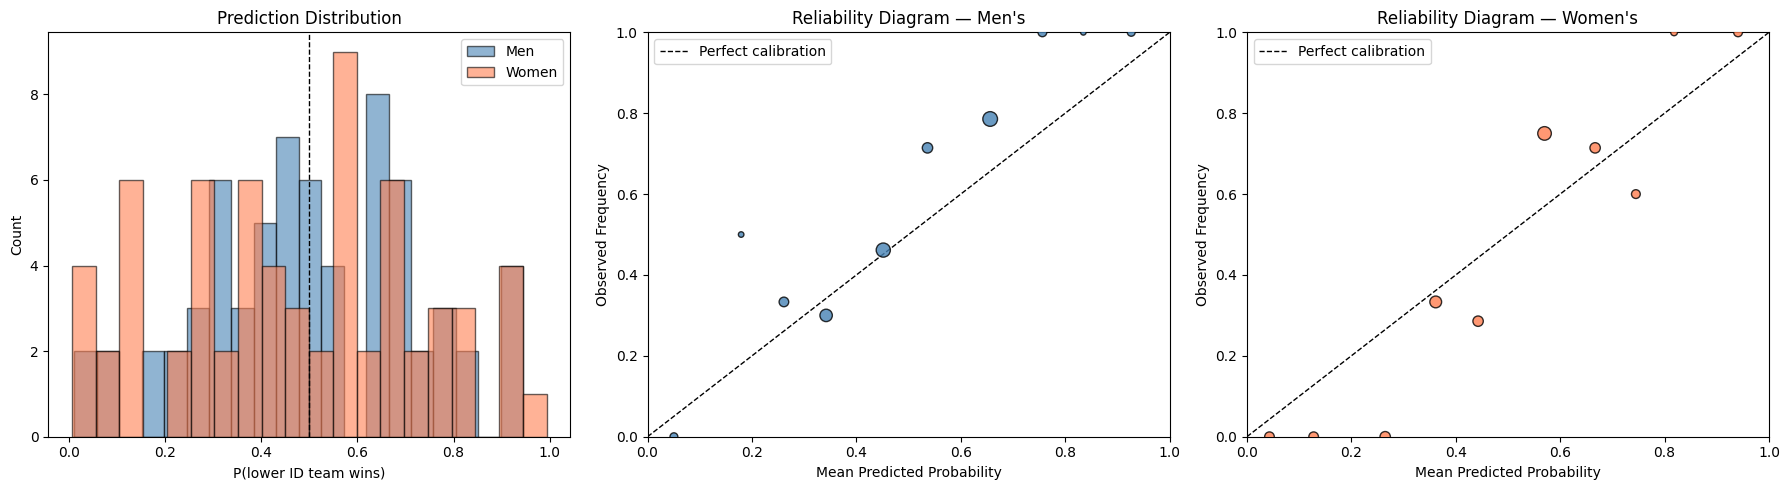

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Prediction distribution
for results, label, color in [(m_results, "Men", "steelblue"), (w_results, "Women", "coral")]:
    axes[0].hist(results["pred"], bins=20, alpha=0.6, color=color, label=label, edgecolor="black")
axes[0].axvline(0.5, color="black", linestyle="--", linewidth=1)
axes[0].set_title("Prediction Distribution")
axes[0].set_xlabel("P(lower ID team wins)")
axes[0].set_ylabel("Count")
axes[0].legend()

# 2. Reliability diagram (Men's)
for ax, results, label in [(axes[1], m_results, "Men's"), (axes[2], w_results, "Women's")]:
    y_true = results["target"].values
    y_pred = results["pred"].values
    
    # Bin predictions
    n_bins = 10
    bin_edges = np.linspace(0, 1, n_bins + 1)
    bin_centers = []
    bin_means = []
    bin_counts = []
    
    for i in range(n_bins):
        mask = (y_pred >= bin_edges[i]) & (y_pred < bin_edges[i + 1])
        if i == n_bins - 1:  # include right edge for last bin
            mask = (y_pred >= bin_edges[i]) & (y_pred <= bin_edges[i + 1])
        if mask.sum() > 0:
            bin_centers.append(y_pred[mask].mean())
            bin_means.append(y_true[mask].mean())
            bin_counts.append(mask.sum())
    
    ax.plot([0, 1], [0, 1], "k--", linewidth=1, label="Perfect calibration")
    ax.scatter(bin_centers, bin_means, s=[c * 8 for c in bin_counts], 
               color="steelblue" if "Men" in label else "coral", 
               edgecolor="black", zorder=5, alpha=0.8)
    ax.set_title(f"Reliability Diagram — {label}")
    ax.set_xlabel("Mean Predicted Probability")
    ax.set_ylabel("Observed Frequency")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.legend()

plt.tight_layout()
plt.show()

## Biggest Upsets (where model was most wrong)

In [8]:
# Show games where the model was most confident but wrong
for results, label in [(m_results, "Men's"), (w_results, "Women's")]:
    r = results.copy()
    r["error"] = (r["pred"] - r["target"]).abs()
    r["correct"] = ((r["pred"] >= 0.5).astype(int) == r["target"]).astype(int)
    worst = r.sort_values("error", ascending=False).head(10)
    
    print(f"\n{label} — Top 10 biggest misses:")
    print(f"{'TeamA':>8} {'TeamB':>8} {'Pred':>8} {'Actual':>8} {'Error':>8}")
    print("-" * 45)
    for _, row in worst.iterrows():
        winner = "TeamA" if row["target"] == 1 else "TeamB"
        print(f"{int(row['TeamA']):>8} {int(row['TeamB']):>8} {row['pred']:>8.3f} {int(row['target']):>8} {row['error']:>8.3f}  ({winner} won)")


Men's — Top 10 biggest misses:
   TeamA    TeamB     Pred   Actual    Error
---------------------------------------------
    1116     1385    0.174        1    0.826  (TeamA won)
    1161     1272    0.280        1    0.720  (TeamA won)
    1116     1242    0.283        1    0.717  (TeamA won)
    1120     1196    0.677        0    0.677  (TeamB won)
    1140     1458    0.364        1    0.636  (TeamA won)
    1124     1280    0.366        1    0.634  (TeamA won)
    1155     1270    0.632        0    0.632  (TeamB won)
    1104     1181    0.619        0    0.619  (TeamB won)
    1140     1433    0.388        1    0.612  (TeamA won)
    1166     1257    0.434        1    0.566  (TeamA won)

Women's — Top 10 biggest misses:
   TeamA    TeamB     Pred   Actual    Error
---------------------------------------------
    3124     3279    0.709        0    0.709  (TeamB won)
    3143     3280    0.709        0    0.709  (TeamB won)
    3166     3228    0.690        0    0.690  (TeamB won